# Clustering Categorical Data 

You are given much more country data. Using the same methodology as the one in the lecture, group all the countries in 2 clusters. 

<b> Already done that? Okay! </b>
    
There are other features: name and continent. 

Encode the continent one and use it in the clustering solution. Think about the difference with the previous exercise.

## Import the relevant libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn
seaborn.set_theme()

## Load the data

Load data from the csv file: <i> 'Categorical.csv'</i>.

In [4]:
raw_data=pd.read_csv('Categorical.csv')
raw_data.head(30)

,name,Longitude,Latitude,continent
0,Aruba,-69.982677,12.520880,North America
1,Afghanistan,66.004734,33.835231,Asia
2,Angola,17.537368,-12.293361,Africa
3,Anguilla,-63.064989,18.223959,North America
4,Albania,20.049834,41.142450,Europe
5,Aland,19.953288,60.214887,Europe
6,Andorra,1.560544,42.542291,Europe
7,United Arab Emirates,54.300167,23.905282,Asia
8,Argentina,-65.179807,-35.381349,South America
9,Armenia,44.929933,40.289526,Asia


Remove the duplicate index column from the dataset. 

## Map the data

Use the <i>'continent'</i> category for this analysis.

In [44]:
data=raw_data.copy()
data['continent']=data['continent'].map({'Africa':0,'Antarctica':1,'Asia':2,'Europe':3,'North America':4,'Oceania':5,'Seven seas (open ocean)':6,'South America':7})
data.head(30)

,name,Longitude,Latitude,continent
0,Aruba,-69.982677,12.520880,4
1,Afghanistan,66.004734,33.835231,2
2,Angola,17.537368,-12.293361,0
3,Anguilla,-63.064989,18.223959,4
4,Albania,20.049834,41.142450,3
5,Aland,19.953288,60.214887,3
6,Andorra,1.560544,42.542291,3
7,United Arab Emirates,54.300167,23.905282,2
8,Argentina,-65.179807,-35.381349,7
9,Armenia,44.929933,40.289526,2


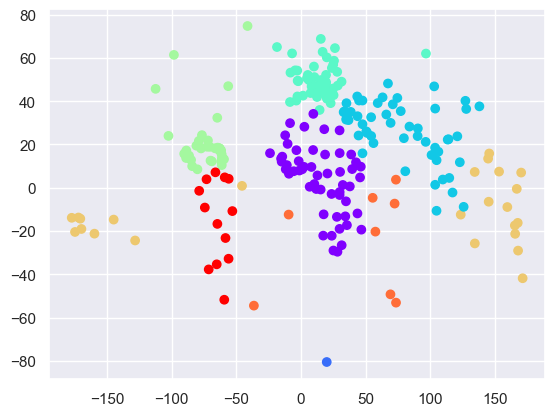

In [45]:
continents=['Africa','Antarctica','Asia','Europe','North America','Oceania','South America','Seven seas (open ocean)']
plt.scatter(data['Longitude'],data['Latitude'], c=data['continent'],cmap='rainbow')
plt.show()

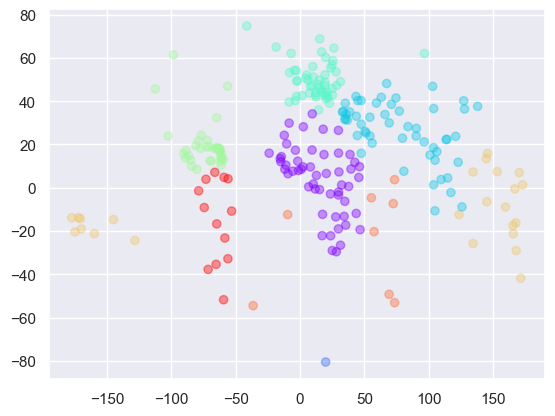

In [46]:
#     Kiribati 	-45.611105 	0.860015
#real Kiribati: 1.3259876,172.9892773
data.loc[data['name']=='Kiribati', 'Longitude'] = 172.9892773
data.loc[data['name']=='Kiribati', 'Latitude'] = 1.3259876
# Greenland is in Europe
data.loc[data['name']=='Greenland', 'continent'] = 3
plt.scatter(data['Longitude'],data['Latitude'], c=data['continent'],cmap='rainbow',alpha=0.4)
plt.show()

## Select the features

In [49]:
x=data[['Longitude','Latitude','continent']]

,Longitude,Latitude,continent
0,-69.982677,12.520880,4
1,66.004734,33.835231,2
2,17.537368,-12.293361,0
3,-63.064989,18.223959,4
4,20.049834,41.142450,3
...,...,...,...
236,-172.164851,-13.753243,5
237,47.586762,15.909280,2
238,25.083901,-29.000341,0
239,27.774759,-13.458242,0


## Clustering

Use 4 clusters initially.

In [73]:
kmeans=KMeans(8)
kmeans.fit(x)

,n_clusters,8
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


## Clustering results

In [74]:
identified_clusters = kmeans.fit_predict(x)
identified_clusters

array([1, 3, 7, 1, 0, 0, 0, 3, 1, 3, 6, 7, 4, 7, 1, 4, 0, 3, 7, 0, 5, 5,
       2, 0, 3, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 2, 2, 7, 5, 0, 1, 2, 5, 5,
       7, 5, 6, 1, 7, 5, 1, 1, 1, 1, 3, 3, 0, 0, 3, 1, 0, 1, 5, 1, 3, 3,
       0, 0, 3, 0, 4, 1, 0, 0, 4, 5, 0, 3, 0, 5, 5, 5, 5, 5, 0, 1, 0, 1,
       4, 1, 2, 7, 1, 0, 1, 0, 2, 0, 2, 2, 7, 0, 3, 3, 0, 3, 0, 1, 0, 3,
       2, 3, 3, 7, 3, 2, 4, 1, 2, 0, 3, 2, 3, 5, 0, 1, 0, 2, 7, 0, 0, 0,
       2, 1, 5, 0, 0, 7, 3, 1, 4, 0, 5, 0, 2, 0, 2, 4, 7, 5, 1, 7, 7, 2,
       7, 4, 5, 4, 5, 1, 6, 0, 0, 2, 4, 4, 3, 3, 1, 6, 1, 2, 4, 4, 0, 1,
       2, 0, 1, 3, 6, 3, 0, 2, 7, 5, 3, 3, 7, 5, 2, 5, 5, 4, 5, 1, 0, 3,
       3, 1, 0, 5, 1, 0, 0, 0, 7, 1, 7, 3, 1, 5, 5, 2, 3, 3, 4, 6, 1, 0,
       3, 2, 7, 7, 0, 1, 1, 3, 0, 1, 1, 1, 1, 2, 4, 6, 6, 3, 7, 7, 7],
      dtype=int32)

In [75]:
data_with_clusters = data.copy()
data_with_clusters['Cluster'] = identified_clusters
data_with_clusters

,name,Longitude,Latitude,continent,Cluster
0,Aruba,-69.982677,12.520880,4,1
1,Afghanistan,66.004734,33.835231,2,3
2,Angola,17.537368,-12.293361,0,7
3,Anguilla,-63.064989,18.223959,4,1
4,Albania,20.049834,41.142450,3,0
...,...,...,...,...,...
236,Samoa,-172.164851,-13.753243,5,6
237,Yemen,47.586762,15.909280,2,3
238,South Africa,25.083901,-29.000341,0,7
239,Zambia,27.774759,-13.458242,0,7


## Plot the data

<function matplotlib.pyplot.show(close=None, block=None)>

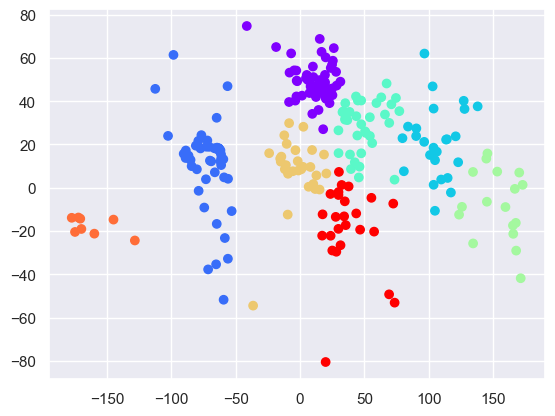

In [76]:
plt.scatter(data_with_clusters['Longitude'],data_with_clusters['Latitude'],c=data_with_clusters['Cluster'],cmap='rainbow')
plt.show

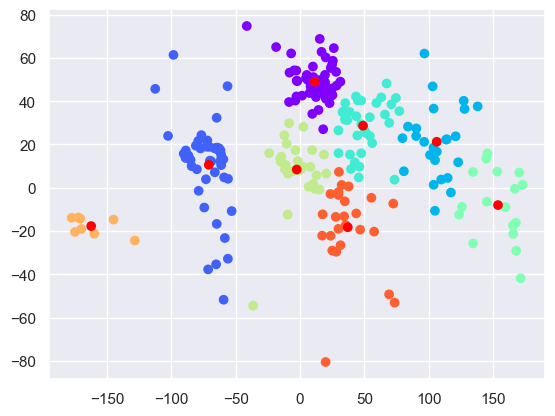

In [77]:
centroids = pd.DataFrame(kmeans.cluster_centers_)
new_columns = ['Longitude','Latitude','continent']
centroids.columns = new_columns
centroids['Cluster'] = centroids.shape[0]
data_with_centroids = pd.concat([data_with_clusters,centroids]).reset_index(drop=True)
plt.scatter(data_with_centroids['Longitude'],data_with_centroids['Latitude'],c=data_with_centroids['Cluster'],cmap='rainbow')
plt.show()

Since you already have all the code necessary, go back and play around with the number of clusters. Try 3, 7 and 8 and see if the results match your expectations. 

Simply go back to the beggining of the <b> Clustering </b> section and change <i> kmeans = KMeans(4) </i> to <i> kmeans = KMeans(3) </i>. Then run the remaining cells until the end.